# Phase I · Week 1 · Broadcasting

Segundo notebook de la Wk 1. La primera mitad cubrió las cinco operaciones de vecindad (histograma, threshold, PSNR, filtro media, dilation). Esta segunda mitad cubre el otro pilar de la fluencia con NumPy: **broadcasting**.

Broadcasting es el mecanismo que permite a NumPy operar entre arrays de diferentes shapes sin escribir bucles ni copiar memoria explícitamente. Es la diferencia entre escribir 10 líneas para normalizar una imagen y escribir una sola.

En este notebook se cubren cuatro ejercicios:

1. **Predicción de shapes**: dado un par de arrays, predecir si la operación funciona y qué shape tendrá el resultado.
2. **Casos en los que broadcasting falla**: identificar cuándo dos shapes no son compatibles y aplicar `reshape` o `np.newaxis` para hacerlos encajar.
3. **Normalización de una imagen RGB**: restar la media y dividir por la desviación estándar de cada canal en una sola línea.
4. **Distancia desde el centro**: construir una matriz donde cada celda contiene la distancia euclídea hasta el centro de la imagen.

Estas técnicas se usan literalmente en cada paso del pipeline de deep learning posterior — preprocesado de imágenes, normalización por batch, generación de máscaras, atención posicional, etc.

## Imports

In [2]:
import numpy as np

## Reglas de broadcasting (referencia rápida)

NumPy puede operar dos arrays de shapes diferentes si, leyendo las dimensiones **de derecha a izquierda**, en cada posición se cumple una de estas condiciones:

- Las dos dimensiones son iguales.
- Una de ellas es 1 (entonces NumPy la "estira" virtualmente para igualar la otra).
- Una de las dos no existe (se asume 1).

Si no se cumple ninguna de las tres en alguna dimensión, NumPy lanza `ValueError: operands could not be broadcast together`.

Ejemplos compatibles:

```
(2, 3)  +  (3,)        → resultado (2, 3)   [la segunda se trata como (1, 3)]
(4, 1)  +  (1, 5)      → resultado (4, 5)   [ambas se estiran]
(256, 256, 3)  -  (3,) → resultado (256, 256, 3)  [normalización por canal]
(N, H, W)  /  (N, 1, 1)→ resultado (N, H, W)      [normalización por imagen en una batch]
```

Ejemplos incompatibles:

```
(4, 3)  +  (4,)   → ERROR  [la (4,) se trata como (1, 4); 3 ≠ 4]
(2, 3)  +  (3, 2) → ERROR  [3 ≠ 2 en la última posición]
```

La regla mental: alinea las shapes por la derecha y comprueba columna por columna.

## Ejercicio 3.1 · Predicción de shapes


In [3]:
a = np.array([[1, 2, 3],
                [4, 5, 6]])     # shape (2, 3)
b = np.array([10, 20, 30])    # shape (3,)
result = a + b

print(result.shape)
print(result)
print(result[1, 2])

(2, 3)
[[11 22 33]
 [14 25 36]]
36


## Ejercicio 3.2 · ¿Cuándo NO funciona broadcasting?

El siguiente código rompe. Predice el error antes de ejecutarlo.

In [4]:

a = np.zeros((4, 3))
b = np.zeros(4)


try:
    result = a + b
    print(result)
except ValueError as e:
    print(e)


operands could not be broadcast together with shapes (4,3) (4,) 


### Arreglo

Para que `b` se reste/sume a cada **fila** de `a`, hay que cambiar su shape de `(4,)` a `(4, 1)`. NumPy ofrece dos formas equivalentes:

- `b.reshape(4, 1)` — devuelve una vista con el nuevo shape.
- `b[:, np.newaxis]` — equivalente, sintaxis de slicing.
- `b[:, None]` — equivalente, `None` es alias de `np.newaxis`.

Con shape `(4, 1)`, alineando por la derecha contra `(4, 3)`:

- Última dim: 1 vs 3 → se estira a 3.
- Siguiente: 4 vs 4 → coinciden.

Y broadcasting funciona.

In [5]:
a = np.zeros((4, 3))
b = np.zeros(4)
b = b.reshape(-1, 1)
result = a + b

print(b.shape)
print(result.shape)
print(result)


(4, 1)
(4, 3)
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## Ejercicio 3.3 · Normalizar una imagen RGB

La normalización por canal (restar media, dividir por std) es uno de los preprocesados más usados antes de meter una imagen a una red neuronal. Sin broadcasting habría que escribir un bucle sobre los tres canales. Con broadcasting es una sola línea.

Pasos:

1. Crear una imagen RGB sintética de shape `(256, 256, 3)`.
2. Calcular la media de cada canal — debería tener shape `(3,)`.
3. Calcular la std de cada canal — también `(3,)`.
4. Normalizar la imagen: restar la media y dividir por la std.



In [6]:
img_rgb = np.random.randint(0,256,size=(256,256,3), dtype=np.uint8)
img_rgb = img_rgb.astype(np.float32)

print(img_rgb.dtype, img_rgb.min(), img_rgb.max())

float32 0.0 255.0


In [7]:
canal_media =np.mean(img_rgb, axis=(0, 1))

print(canal_media.shape, canal_media)

(3,) [127.36325 127.05208 127.09032]


In [8]:
canal_std = np.std(img_rgb, axis=(0, 1))

print(canal_std.shape, canal_std)

(3,) [73.73793 73.83756 73.99441]


In [9]:
img_norm =(img_rgb - canal_media) / canal_std

print(np.mean(img_norm, axis=(0, 1)))
print(np.std(img_norm, axis=(0, 1)))

[ 4.9394657e-09 -1.0799340e-08  1.0031727e-08]
[0.99999994 0.9999856  0.9999888 ]


In [13]:
def normalize_per_channel(img):
    """Z-score por canal. Acepta (H, W, 3) uint8/float; devuelve (H, W, 3) float32."""
    img_float = img.astype(np.float32)
    media = np.mean(img_float, axis=(0, 1))
    std = np.std(img_float, axis=(0, 1))
    return (img_float - media) / std


img_norm_v2 = normalize_per_channel(img_rgb)
print(np.mean(img_norm_v2, axis=(0, 1)))
print(np.std(img_norm_v2, axis=(0, 1)))


[ 4.9394657e-09 -1.0799340e-08  1.0031727e-08]
[0.99999994 0.9999856  0.9999888 ]


## Ejercicio 3.4 · Distancia desde el centro (sin bucles)

Construir un array `(256, 256)` donde cada celda contiene la distancia euclídea desde el centro de la imagen `(128, 128)`.

Resultado esperado:

- `result[128, 128] = 0`
- `result[0, 0] ≈ 181.0` (= sqrt(128² + 128²))
- `result[0, 128] = 128`

Visualmente, al hacer `imshow` con un colormap como `hot`, sale un círculo gradiente que es más oscuro en el centro y más claro hacia las esquinas.

Pista: `np.indices((H, W))` devuelve un array de shape `(2, H, W)`. El primer canal contiene las coordenadas Y (filas) y el segundo las coordenadas X (columnas). A partir de ahí, broadcasting + `np.sqrt` resuelve el resto.

Estructura mental:

```
yy, xx = np.indices((256, 256))      # cada uno shape (256, 256)
dy = yy - 128                         # broadcasting
dx = xx - 128
dist = np.sqrt(dy**2 + dx**2)
```

Esta operación aparece en muchas máscaras radiales (filtros circulares, atención posicional, etc.).

In [10]:
i, j= np.indices((256, 256))
dy = j - 128
dx = i - 128
dist = np.sqrt(dy**2 + dx**2)

print(dist.shape)
print(dist[128,128])
print(dist[0,0])
print(dist[128, 0])

(256, 256)
0.0
181.01933598375618
128.0


In [14]:
def distance_map(shape, center=None):
    """Mapa de distancia euclídea desde un punto. Por defecto, el centro geométrico."""
    if center is None:
        center = (shape[0] // 2, shape[1] // 2)
    cy, cx = center

    i, j = np.indices(shape)
    return np.sqrt((i - cy) ** 2 + (j - cx) ** 2)

dist_v2 = distance_map((256, 256))
print(dist_v2.shape, dist_v2[128, 128], dist_v2[0, 0])

dist_off = distance_map((256, 256), center=(50, 200))
print(dist_off[50, 200])
print(dist_off[50, 0])

(256, 256) 0.0 181.01933598375618
0.0
200.0


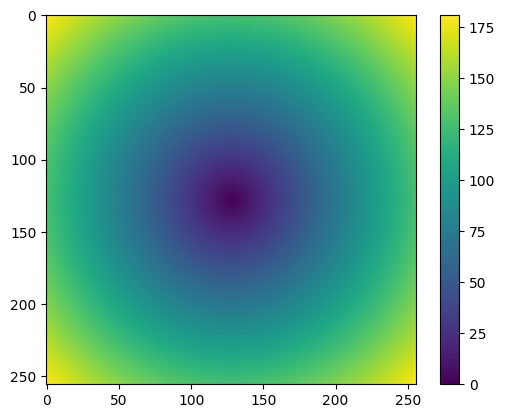

In [11]:
import matplotlib.pyplot as plt
plt.imshow(dist, cmap='viridis')
plt.colorbar()
plt.show()

## Cierre del Wk 1

Con esto se cierran los dos pilares de NumPy:

- **Vectorización** (notebook 1): usar funciones de NumPy en lugar de bucles Python.
- **Broadcasting** (este notebook): operar entre arrays de diferentes shapes sin replicar datos.

Combinando los dos, la mayoría del procesado clásico de imagen y todos los preprocesados antes de una red neuronal se escriben en pocas líneas.

Próximo paso del roadmap: Wk 2 — Álgebra lineal aplicada (SVD, descomposición espectral, compresión de imagen).